<a href="https://www.kaggle.com/code/sofiatanganho/2-0-modela-o-treino?scriptVersionId=319314603" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Análise Preditiva do Mercado Imobiliário de Boston
#### Grupo 10: Diana Figueiredo, Natacha Zhang, Sofia Tanganho
#### Docente: Dora Melo 

## Importação de Bibliotecas
(Diana Figueiredo)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from scipy.stats import kstest, norm

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import (
    train_test_split,
    KFold,
    ParameterGrid,
    GridSearchCV,           
    RandomizedSearchCV,    
    cross_validate,        
    learning_curve          
)
from sklearn.pipeline import Pipeline                  
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,    
    davies_bouldin_score        
)

from xgboost import XGBRegressor

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/natachazhang/dados-processados/boston_processed.csv


In [3]:
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("/kaggle/input/datasets/natachazhang/dados-processados/boston_processed.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ZN          506 non-null    float64
 1   INDUS       506 non-null    float64
 2   CHAS        506 non-null    int64  
 3   AGE         506 non-null    float64
 4   TAX         506 non-null    float64
 5   B           506 non-null    float64
 6   MEDV        506 non-null    float64
 7   B_stand     506 non-null    float64
 8   ZN_stand    506 non-null    float64
 9   INDUS_norm  506 non-null    float64
 10  AGE_norm    506 non-null    float64
 11  TAX_norm    506 non-null    float64
 12  IQV         506 non-null    float64
 13  IAH         506 non-null    float64
 14  IQV_stand   506 non-null    float64
 15  IAH_stand   506 non-null    float64
dtypes: float64(15), int64(1)
memory usage: 63.4 KB


## Objetivo 1: Construir um modelo de previsão supervisionada do preço médio das habitações (MEDV), alcançando um R² superior a 0.80 e um RMSE inferior a 3.500 dólares, até ao Milestone 3.
### Baseline: 
- Regressão Linear 
### Algoritmos candidatos:
- Random Forest
- XGBoost
- SVR




### Experimentação de valores para treino de 80% e teste de 20%
(Sofia Tanganho)

In [5]:
# Divisão 80% treino / 20% teste
X = df[[
    'ZN_stand',      
    'INDUS_norm',   
    'CHAS',          
    'AGE_norm',      
    'TAX_norm',     
    'B_stand',       
    'IQV_stand',    
    'IAH_stand'     
]]

y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treino: {X_train.shape}")
print(f"Teste: {X_test.shape}")

Treino: (404, 8)
Teste: (102, 8)


In [6]:
baseline = LinearRegression()
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

rmse_bl = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae_bl = mean_absolute_error(y_test, y_pred_baseline)
r2_bl = r2_score(y_test, y_pred_baseline)

print('Regressão Linear')
print(f"RMSE: {rmse_bl:.4f}")
print(f"MAE:  {mae_bl:.4f}")
print(f"R²:   {r2_bl:.4f}")

Regressão Linear
RMSE: 4.7511
MAE:  3.3544
R²:   0.6922


## Modelos candidatos 

(Natacha Zhang) 

Testaram-se três algoritmos:

* **Random Forest** – Algoritmo de ensemble que utiliza várias árvores de decisão para melhorar a performance, destacando-se pela sua robustez a outliers e capacidade de lidar com variáveis heterogéneas.
  
* **XGBoost** – Algoritmo de boosting avançado que constrói modelos de forma sequencial, corrigindo os erros das iterações anteriores e incorporando regularização para reduzir o overfitting.

* **SVR** – Modelo de regressão baseado em vetores de suporte que procura encontrar a função que melhor se ajusta aos dados dentro de uma margem de tolerância definida.

In [7]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf_train = rf.predict(X_train)
y_pred_rf_test = rf.predict(X_test)

rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
mae_rf_train = mean_absolute_error(y_train, y_pred_rf_train)
mae_rf_test = mean_absolute_error(y_test, y_pred_rf_test)
r2_rf_train = r2_score(y_train, y_pred_rf_train)
r2_rf_test = r2_score(y_test, y_pred_rf_test)

print("Random Forest")
print(f"RMSE Treino: {rmse_rf_train:.4f} | RMSE Teste: {rmse_rf_test:.4f}")
print(f"MAE  Treino: {mae_rf_train:.4f} | MAE  Teste: {mae_rf_test:.4f}")
print(f"R²   Treino: {r2_rf_train:.4f} | R²   Teste: {r2_rf_test:.4f}")

Random Forest
RMSE Treino: 1.5205 | RMSE Teste: 3.8309
MAE  Treino: 1.0570 | MAE  Teste: 2.6729
R²   Treino: 0.9734 | R²   Teste: 0.7999


In [8]:
# XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb_train = xgb.predict(X_train)
y_pred_xgb_test = xgb.predict(X_test)

rmse_xgb_train = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))
rmse_xgb_test = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))
mae_xgb_train = mean_absolute_error(y_train, y_pred_xgb_train)
mae_xgb_test = mean_absolute_error(y_test, y_pred_xgb_test)
r2_xgb_train = r2_score(y_train, y_pred_xgb_train)
r2_xgb_test = r2_score(y_test, y_pred_xgb_test)

print("XGBOOST")
print(f"RMSE Treino: {rmse_xgb_train:.4f} | RMSE Teste: {rmse_xgb_test:.4f}")
print(f"MAE  Treino: {mae_xgb_train:.4f} | MAE  Teste: {mae_xgb_test:.4f}")
print(f"R²   Treino: {r2_xgb_train:.4f} | R²   Teste: {r2_xgb_test:.4f}")

XGBOOST
RMSE Treino: 0.0509 | RMSE Teste: 3.6863
MAE  Treino: 0.0356 | MAE  Teste: 2.7311
R²   Treino: 1.0000 | R²   Teste: 0.8147


In [9]:
# SVR precisa de dados normalizados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Treinar SVR
svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train)

# Métricas Treino
y_pred_svr_train = svr.predict(X_train_scaled)
rmse_svr_train = np.sqrt(mean_squared_error(y_train, y_pred_svr_train))
mae_svr_train = mean_absolute_error(y_train, y_pred_svr_train)
r2_svr_train = r2_score(y_train, y_pred_svr_train)

# Métricas Teste
y_pred_svr_test = svr.predict(X_test_scaled)
rmse_svr_test = np.sqrt(mean_squared_error(y_test, y_pred_svr_test))
mae_svr_test = mean_absolute_error(y_test, y_pred_svr_test)
r2_svr_test = r2_score(y_test, y_pred_svr_test)

print("SVR")
print(f"RMSE Treino: {rmse_svr_train:.4f} | RMSE Teste: {rmse_svr_test:.4f}")
print(f"MAE  Treino: {mae_svr_train:.4f} | MAE  Teste: {mae_svr_test:.4f}")
print(f"R²   Treino: {r2_svr_train:.4f} | R²   Teste: {r2_svr_test:.4f}")

SVR
RMSE Treino: 5.8203 | RMSE Teste: 5.7306
MAE  Treino: 3.8342 | MAE  Teste: 3.4481
R²   Treino: 0.6101 | R²   Teste: 0.5522


In [10]:
resultados = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost', 'SVR'],
    'RMSE Treino': [ rmse_rf_train, rmse_xgb_train, rmse_svr_train],
    'RMSE Teste':  [ rmse_rf_test, rmse_xgb_test, rmse_svr_test],
    'MAE Treino':  [ mae_rf_train, mae_xgb_train, mae_svr_train],
    'MAE Teste':   [ mae_rf_test, mae_xgb_test, mae_svr_test],
    'R² Treino':   [ r2_rf_train, r2_xgb_train, r2_svr_train],
    'R² Teste':    [ r2_rf_test, r2_xgb_test, r2_svr_test]
})

print("Resultados dos modelos usando divisão treino/teste (80%/20%)")
print(resultados.to_string(index=False))

Resultados dos modelos usando divisão treino/teste (80%/20%)
       Modelo  RMSE Treino  RMSE Teste  MAE Treino  MAE Teste  R² Treino  R² Teste
Random Forest     1.520516    3.830944    1.056970   2.672922   0.973387  0.799872
      XGBoost     0.050864    3.686294    0.035627   2.731074   0.999970  0.814700
          SVR     5.820313    5.730591    3.834192   3.448100   0.610053  0.552189


#### Observações:

O **XGBoost** destaca-se como o modelo com melhor desempenho, apresentando o RMSE de teste mais baixo (3.686) e um R² de teste de 0.81, acima do objetivo SMART definido (R² > 0.80). O **Random Forest** apresenta resultados igualmente satisfatórios (R² teste = 0.80), no entanto ambos revelam sinais de overfitting, com valores de R² de treino muito superiores aos de teste.
O **SVR** apresenta o desempenho mais fraco, não atingindo o objetivo definido (R² teste = 0.56).

### Experimentação de valores para treino de 70% e teste de 30%
(Sofia Tanganho)

In [11]:
X = df[[
    'ZN_stand',      
    'INDUS_norm',    
    'CHAS',          
    'AGE_norm',      
    'TAX_norm',      
    'B_stand',       
    'IQV_stand',   
    'IAH_stand'      
]]

y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Treino: {X_train.shape}")
print(f"Teste: {X_test.shape}")

Treino: (354, 8)
Teste: (152, 8)


In [12]:
# Treinar Baseline
baseline = LinearRegression()
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)


rmse_bl = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae_bl = mean_absolute_error(y_test, y_pred_baseline)
r2_bl = r2_score(y_test, y_pred_baseline)

print("Regressão Linear")
print(f"RMSE: {rmse_bl:.4f}")
print(f"MAE:  {mae_bl:.4f}")
print(f"R²:   {r2_bl:.4f}")

Regressão Linear
RMSE: 4.8757
MAE:  3.5549
R²:   0.6810


In [13]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf_train = rf.predict(X_train)
y_pred_rf_test = rf.predict(X_test)

rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
mae_rf_train = mean_absolute_error(y_train, y_pred_rf_train)
mae_rf_test = mean_absolute_error(y_test, y_pred_rf_test)
r2_rf_train = r2_score(y_train, y_pred_rf_train)
r2_rf_test = r2_score(y_test, y_pred_rf_test)

print("RANDOM FOREST")
print(f"RMSE Treino: {rmse_rf_train:.4f} | RMSE Teste: {rmse_rf_test:.4f}")
print(f"MAE  Treino: {mae_rf_train:.4f} | MAE  Teste: {mae_rf_test:.4f}")
print(f"R²   Treino: {r2_rf_train:.4f} | R²   Teste: {r2_rf_test:.4f}")

RANDOM FOREST
RMSE Treino: 1.6594 | RMSE Teste: 3.5936
MAE  Treino: 1.1323 | MAE  Teste: 2.5627
R²   Treino: 0.9687 | R²   Teste: 0.8267


In [14]:
# XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb_train = xgb.predict(X_train)
y_pred_xgb_test = xgb.predict(X_test)

rmse_xgb_train = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))
rmse_xgb_test = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))
mae_xgb_train = mean_absolute_error(y_train, y_pred_xgb_train)
mae_xgb_test = mean_absolute_error(y_test, y_pred_xgb_test)
r2_xgb_train = r2_score(y_train, y_pred_xgb_train)
r2_xgb_test = r2_score(y_test, y_pred_xgb_test)

print("XGBOOST")
print(f"RMSE Treino: {rmse_xgb_train:.4f} | RMSE Teste: {rmse_xgb_test:.4f}")
print(f"MAE  Treino: {mae_xgb_train:.4f} | MAE  Teste: {mae_xgb_test:.4f}")
print(f"R²   Treino: {r2_xgb_train:.4f} | R²   Teste: {r2_xgb_test:.4f}")

XGBOOST
RMSE Treino: 0.0561 | RMSE Teste: 3.7102
MAE  Treino: 0.0382 | MAE  Teste: 2.7212
R²   Treino: 1.0000 | R²   Teste: 0.8153


In [15]:
# SVR precisa de dados normalizados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Treinar SVR
svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train)

# Métricas Treino
y_pred_svr_train = svr.predict(X_train_scaled)
rmse_svr_train = np.sqrt(mean_squared_error(y_train, y_pred_svr_train))
mae_svr_train = mean_absolute_error(y_train, y_pred_svr_train)
r2_svr_train = r2_score(y_train, y_pred_svr_train)

# Métricas Teste
y_pred_svr_test = svr.predict(X_test_scaled)
rmse_svr_test = np.sqrt(mean_squared_error(y_test, y_pred_svr_test))
mae_svr_test = mean_absolute_error(y_test, y_pred_svr_test)
r2_svr_test = r2_score(y_test, y_pred_svr_test)

print("SVR")
print(f"RMSE Treino: {rmse_svr_train:.4f} | RMSE Teste: {rmse_svr_test:.4f}")
print(f"MAE  Treino: {mae_svr_train:.4f} | MAE  Teste: {mae_svr_test:.4f}")
print(f"R²   Treino: {r2_svr_train:.4f} | R²   Teste: {r2_svr_test:.4f}")

SVR
RMSE Treino: 6.0765 | RMSE Teste: 5.7668
MAE  Treino: 4.0072 | MAE  Teste: 3.7572
R²   Treino: 0.5799 | R²   Teste: 0.5537


In [16]:
# Tabela Comparativa
resultados = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost', 'SVR'],
    'RMSE Treino': [ rmse_rf_train, rmse_xgb_train, rmse_svr_train],
    'RMSE Teste':  [ rmse_rf_test, rmse_xgb_test, rmse_svr_test],
    'MAE Treino':  [ mae_rf_train, mae_xgb_train, mae_svr_train],
    'MAE Teste':   [ mae_rf_test, mae_xgb_test, mae_svr_test],
    'R² Treino':   [ r2_rf_train, r2_xgb_train, r2_svr_train],
    'R² Teste':    [ r2_rf_test, r2_xgb_test, r2_svr_test]
})

print("Resultados dos modelos usando divisão treino/teste (70%/30%)")
print(resultados.to_string(index=False))

Resultados dos modelos usando divisão treino/teste (70%/30%)
       Modelo  RMSE Treino  RMSE Teste  MAE Treino  MAE Teste  R² Treino  R² Teste
Random Forest     1.659362    3.593610    1.132251   2.562664   0.968674  0.826688
      XGBoost     0.056141    3.710183    0.038237   2.721180   0.999964  0.815261
          SVR     6.076497    5.766803    4.007240   3.757188   0.579917  0.553689


#### Observações: 

Com a divisão 70%/30%, o **Random Forest** passa a ser o modelo com melhor desempenho, apresentando o RMSE de teste mais baixo (3.594) e um R² de teste de 0.827, acima do objetivo SMART definido (R² > 0.80).O **XGBoost** mantém resultados satisfatórios (R² teste = 0.815), no entanto ambos continuam a revelar sinais de _overfitting_, com valores de R² de treino muito superiores aos de teste. O **SVR** mantém-se como o modelo com pior desempenho, não atingindo o objetivo definido (R² teste = 0.55).

##  Avaliação de Ajuste (Fit) 

Uma vez que tanto o **Random Forest** como o **XGBoost** revelaram sinais de _overfitting_, procedeu-se a uma análise de ajuste (Fit) com o objetivo de compreender melhor o comportamento dos modelos e identificar o mais adequado para a fase de otimização.

(Natacha Zhang)

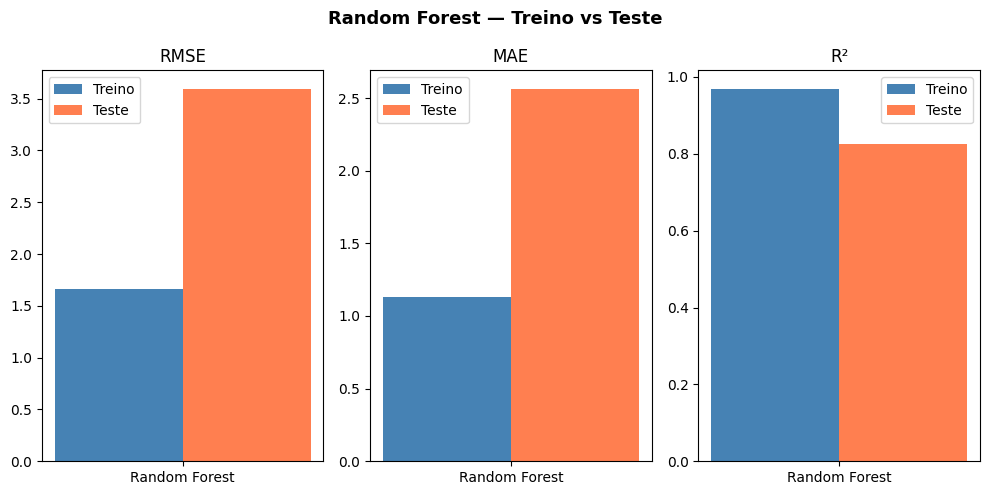

In [17]:

x = np.array([0])
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(10, 5))

# RMSE
axes[0].bar(x - width/2, [rmse_rf_train], width=width, label='Treino', color='steelblue')
axes[0].bar(x + width/2, [rmse_rf_test],  width=width, label='Teste',  color='coral')
axes[0].set_title('RMSE')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Random Forest'])
axes[0].legend()

# MAE
axes[1].bar(x - width/2, [mae_rf_train], width=width, label='Treino', color='steelblue')
axes[1].bar(x + width/2, [mae_rf_test],  width=width, label='Teste',  color='coral')
axes[1].set_title('MAE')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Random Forest'])
axes[1].legend()

# R²
axes[2].bar(x - width/2, [r2_rf_train], width=width, label='Treino', color='steelblue')
axes[2].bar(x + width/2, [r2_rf_test],  width=width, label='Teste',  color='coral')
axes[2].set_title('R²')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Random Forest'])
axes[2].legend()

plt.suptitle('Random Forest — Treino vs Teste', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
def diagnostico_fit(rmse_train, rmse_test, 
                   mae_train, mae_test, 
                   r2_train, r2_test, 
                   nome_modelo):
    
    print(f"{nome_modelo}")
    print(f"RMSE treino: {rmse_train:.4f} | RMSE teste: {rmse_test:.4f}")
    print(f"MAE  treino: {mae_train:.4f}  | MAE  teste: {mae_test:.4f}")
    print(f"R2   treino: {r2_train:.4f} | R2   teste: {r2_test:.4f}")

    # Diferenças
    diff_r2   = r2_train - r2_test
    diff_rmse = rmse_test - rmse_train
    diff_mae  = mae_test - mae_train

    # Diagnóstico
    if r2_train > 0.9 and diff_r2 > 0.1 and diff_rmse > 0 and diff_mae > 0:
        print("Diagnóstico: Overfitting (sobreajuste)")
    
    elif r2_train < 0.7 and r2_test < 0.7:
        print("Diagnóstico: Underfitting (subajuste)")
    
    else:
        print("Diagnóstico: Bom ajuste")
    
diagnostico_fit(rmse_rf_train, rmse_rf_test, mae_rf_train, mae_rf_test,r2_rf_train, r2_rf_test,"Random Forest")


Random Forest
RMSE treino: 1.6594 | RMSE teste: 3.5936
MAE  treino: 1.1323  | MAE  teste: 2.5627
R2   treino: 0.9687 | R2   teste: 0.8267
Diagnóstico: Overfitting (sobreajuste)


#### Conclusões:

A análise de ajuste confirmou os diagnósticos esperados. O **Random Forest** apresenta _overfitting_, com valores de R² de treino (0.97)  muito superior ao de teste (0.83), indicando que o modelos se ajusta demasiado aos dados de treino.O **Random Forest** será sujeito a uma sintonização fina de hiperparâmetros com o objetivo de reduzir o overfitting e melhorar a capacidade de generalização.


## Sintonização Fina (Hyperparameter Tuning)
(Natacha Zhang)

In [19]:
param_grid_rf = {
    'n_estimators':      [100, 200, 300,400],
    'max_depth':         [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
}

gs_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf, cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=0
)

gs_rf.fit(X_train, y_train)

rf_tuned        = gs_rf.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test)
rmse_rf_tuned   = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
r2_rf_tuned     = r2_score(y_test, y_pred_rf_tuned)

print('Randon Forest — Melhores hiperparâmetros:', gs_rf.best_params_)
print(f'  RMSE Teste (otimizado): {rmse_rf_tuned:.4f}')
print(f'  R²   Teste (otimizado): {r2_rf_tuned:.4f}')


Randon Forest — Melhores hiperparâmetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  RMSE Teste (otimizado): 3.5936
  R²   Teste (otimizado): 0.8267


#### Observações:

Após a sintonização fina de hiperparâmetros, o **Random Forest** não registou melhorias após o tuning, mantendo os mesmos valores (RMSE = 3.5936, R² = 0.8267).
Apesar do alargamento intencional dpo intervalo de 'n_estimators', o modelo convergiu consistentemnete para 100 árvores.

## Validação de Robustez
(Sofia Tanganho)

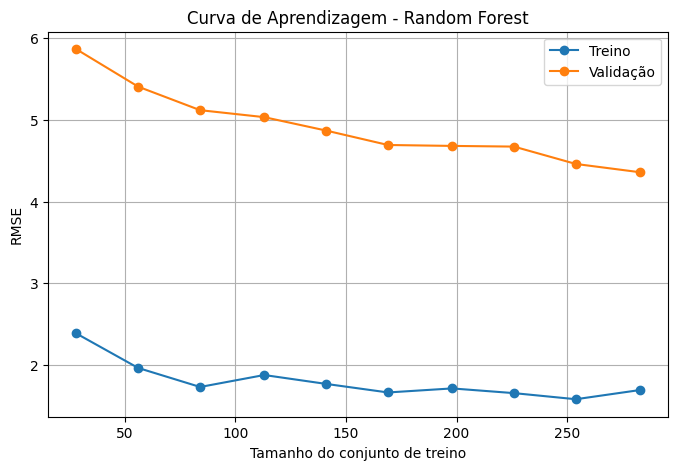

In [20]:
def plot_learning_curve(model, X, y, nome_modelo):
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring='neg_root_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = -train_scores.mean(axis=1)
    test_mean = -test_scores.mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, 'o-', label='Treino')
    plt.plot(train_sizes, test_mean, 'o-', label='Validação')
    plt.title(f'Curva de Aprendizagem - {nome_modelo}')
    plt.xlabel('Tamanho do conjunto de treino')
    plt.ylabel('RMSE')
    plt.legend()
    plt.grid()
    plt.show()

if 'rf' in globals():
    plot_learning_curve(rf, X_train, y_train, "Random Forest")



#### Observações:

As curvas de aprendizagem confirmam os diagnósticos anteriores. O **Random Forest** apresenta uma gap considerável entre treino e validação que se vai reduzindo à medida que o conjunto de treino aumenta, indicando _overfitting_ moderado com tendência a melhorar com mais dados.


## Validação Cruzada (_K-Fold Cross-Validation_)
(Diana Figueiredo)

K-Fold Cross-Validation (k=5) — Regressão

       Modelo  RMSE Média  RMSE Std  MAE Média  MAE Std  R2 Média  R2 Std
Random Forest      4.0259    0.6446     2.8161   0.3153    0.7989  0.0641


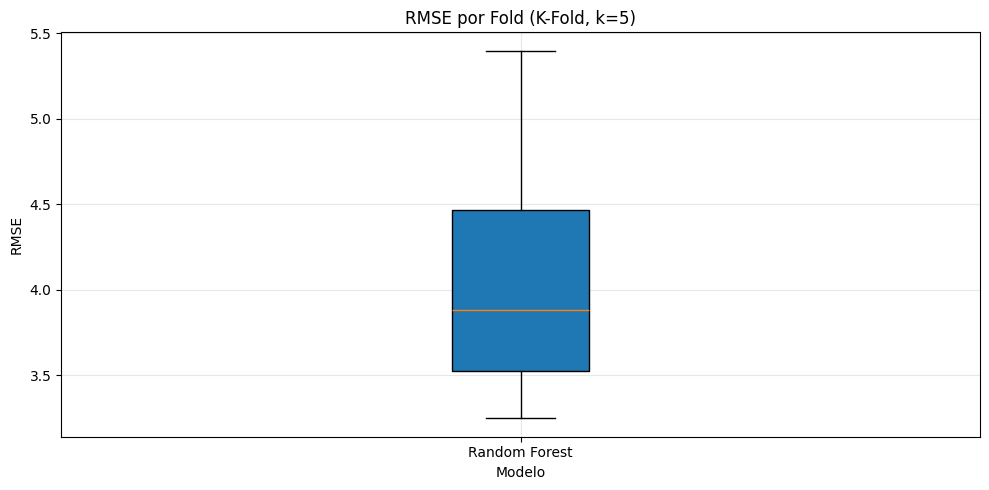

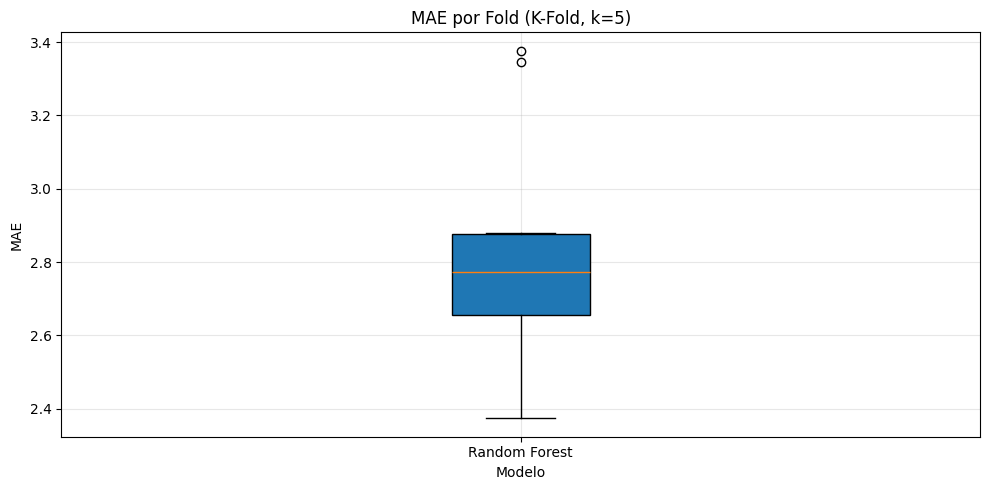

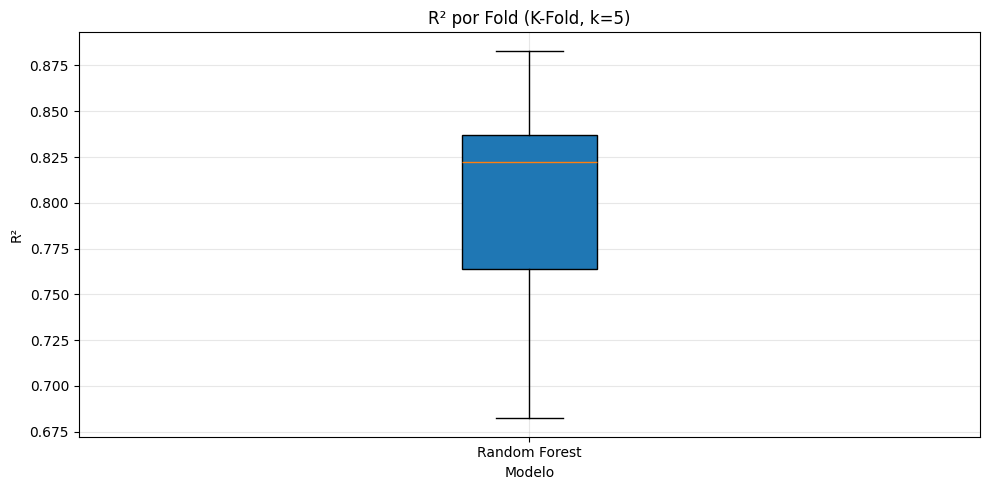

In [21]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)


scoring = {
    'RMSE': 'neg_root_mean_squared_error',
    'MAE':  'neg_mean_absolute_error',
    'R2':   'r2'
}


modelos_cv = {
   # 'Regressão Linear': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
}

resultados_cv = []
rmse_por_modelo = {}
mae_por_modelo = {}
r2_por_modelo = {}

for nome, modelo in modelos_cv.items():
    cv_res = cross_validate(modelo, X, y, cv=kf, scoring=scoring, n_jobs=-1)

    rmse = -cv_res['test_RMSE']
    mae  = -cv_res['test_MAE']
    r2   = cv_res['test_R2']

    rmse_por_modelo[nome] = rmse
    mae_por_modelo[nome]  = mae
    r2_por_modelo[nome]   = r2

    resultados_cv.append({
        'Modelo': nome,
        'RMSE Média': round(rmse.mean(), 4),
        'RMSE Std':   round(rmse.std(), 4),
        'MAE Média':  round(mae.mean(), 4),
        'MAE Std':    round(mae.std(), 4),
        'R2 Média':   round(r2.mean(), 4),
        'R2 Std':     round(r2.std(), 4),
    })


df_cv = pd.DataFrame(resultados_cv)
print("K-Fold Cross-Validation (k=5) — Regressão\n")
print(df_cv.to_string(index=False))


def plot_boxplot(dados, titulo, ylabel):
    plt.figure(figsize=(10,5))
    plt.boxplot(dados.values(), labels=dados.keys(), patch_artist=True)
    plt.title(titulo)
    plt.ylabel(ylabel)
    plt.xlabel('Modelo')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_boxplot(rmse_por_modelo, 'RMSE por Fold (K-Fold, k=5)', 'RMSE')
plot_boxplot(mae_por_modelo,  'MAE por Fold (K-Fold, k=5)',  'MAE')
plot_boxplot(r2_por_modelo,   'R² por Fold (K-Fold, k=5)',   'R²')

#### Observações:

A validação cruzada K-Fold (k=5) confirmou o **Random Forest** como o modelo mais robusto, apresentando o RMSE médio mais baixo (4.073) e o R² médio mais elevado (0.796), com um desvio padrão reduzido (0.055),indicando consistência entre os diferentes folds. A **Regressão Linear** ficou claramente abaixo dos restantes modelos, com R² médios de 0.696 e 0.556 respetivamente, não atingindo o objetivo SMART definido (R² > 0.80).

## Análise de Resultados
(Natacha Zhang)

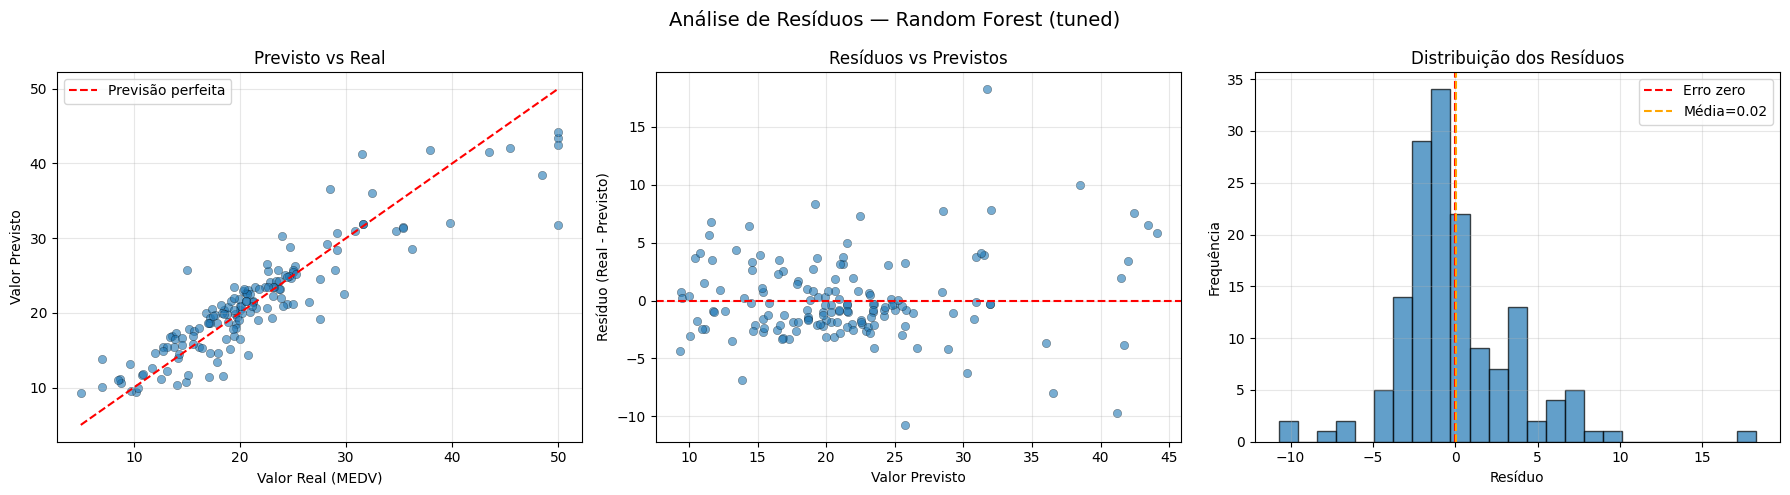


Estatísticas dos Resíduos — Random Forest (tuned)
  Resíduo médio  : 0.0244 
  Desvio padrão  : 3.5935
  Erro máximo    : 18.2760
  Erro mínimo    : -10.7300
  % casos |erro| < 2k$: 51.3%
  % casos |erro| < 5k$: 88.8%

Top 10 piores previsões:
     MEDV_real  MEDV_previsto  Erro_abs
371       50.0         31.724    18.276
375       15.0         25.730    10.730
203       48.5         38.500    10.000
229       31.5         41.213     9.713
409       27.5         19.181     8.319
290       28.5         36.517     8.017
180       39.8         31.981     7.819
181       36.2         28.484     7.716
225       50.0         42.432     7.568
473       29.8         22.494     7.306


In [22]:
# Modelo final — Random Forest (tuned)
nome_modelo_final = 'Random Forest (tuned)'
y_pred_final      = y_pred_rf_tuned
residuos          = y_test.values - y_pred_final

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Previsto vs Real
axes[0].scatter(y_test, y_pred_final, alpha=0.6, edgecolors='k', linewidths=0.3)
lim = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
axes[0].plot(lim, lim, 'r--', label='Previsão perfeita')
axes[0].set_xlabel('Valor Real (MEDV)')
axes[0].set_ylabel('Valor Previsto')
axes[0].set_title('Previsto vs Real')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Resíduos vs Previstos
axes[1].scatter(y_pred_final, residuos, alpha=0.6, edgecolors='k', linewidths=0.3)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Valor Previsto')
axes[1].set_ylabel('Resíduo (Real - Previsto)')
axes[1].set_title('Resíduos vs Previstos')
axes[1].grid(True, alpha=0.3)

# Distribuição dos Resíduos
axes[2].hist(residuos, bins=25, edgecolor='k', alpha=0.7)
axes[2].axvline(0, color='r', linestyle='--', label='Erro zero')
axes[2].axvline(residuos.mean(), color='orange', linestyle='--',
                label=f'Média={residuos.mean():.2f}')
axes[2].set_xlabel('Resíduo')
axes[2].set_ylabel('Frequência')
axes[2].set_title('Distribuição dos Resíduos')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Análise de Resíduos — {nome_modelo_final}', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\nEstatísticas dos Resíduos — {nome_modelo_final}')
print(f'  Resíduo médio  : {residuos.mean():.4f} ')
print(f'  Desvio padrão  : {residuos.std():.4f}')
print(f'  Erro máximo    : {residuos.max():.4f}')
print(f'  Erro mínimo    : {residuos.min():.4f}')
print(f'  % casos |erro| < 2k$: {(np.abs(residuos) < 2).mean()*100:.1f}%')
print(f'  % casos |erro| < 5k$: {(np.abs(residuos) < 5).mean()*100:.1f}%')

df_erros = X_test.copy()
df_erros['MEDV_real']     = y_test.values
df_erros['MEDV_previsto'] = y_pred_final
df_erros['Erro_abs']      = np.abs(residuos)
df_erros = df_erros.sort_values('Erro_abs', ascending=False)

print('\nTop 10 piores previsões:')
print(df_erros[['MEDV_real', 'MEDV_previsto', 'Erro_abs']].head(10).to_string())

Importância de Variáveis:
   Feature  Random Forest
 IAH_stand       0.590397
 IQV_stand       0.116766
  AGE_norm       0.083127
INDUS_norm       0.077707
  TAX_norm       0.059965
   B_stand       0.049034
  ZN_stand       0.017987
      CHAS       0.005017


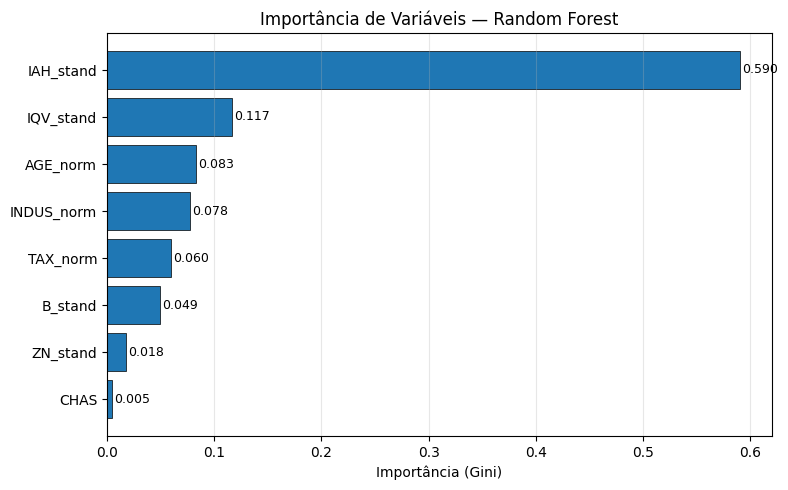

                 Modelo     RMSE       R2
  Random Forest (tuned) 3.593610 0.826688
Regressão Linear (base) 4.875704 0.680962


In [23]:
# Importância de Variáveis — Random Forest
feature_names = [
    'ZN_stand', 'INDUS_norm', 'CHAS', 'AGE_norm',
    'TAX_norm', 'B_stand', 'IQV_stand', 'IAH_stand'
]

importancias_rf = rf_tuned.feature_importances_

df_imp = pd.DataFrame({
    'Feature':       feature_names,
    'Random Forest': importancias_rf,
}).sort_values('Random Forest', ascending=False)

print('Importância de Variáveis:')
print(df_imp.to_string(index=False))

df_plot = df_imp.sort_values('Random Forest', ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(df_plot['Feature'], df_plot['Random Forest'], edgecolor='k', linewidth=0.5)
ax.set_title('Importância de Variáveis — Random Forest', fontsize=12)
ax.set_xlabel('Importância (Gini)')
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, df_plot['Random Forest']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

resumo_final = pd.DataFrame([
    {'Modelo': 'Regressão Linear (base)', 'RMSE': rmse_bl,       'R2': r2_bl},
    {'Modelo': 'Random Forest (tuned)',   'RMSE': rmse_rf_tuned, 'R2': r2_rf_tuned},
]).sort_values('RMSE')

print(resumo_final.to_string(index=False))



#### Conclusôes:

Após a avaliação dos modelos, o **Random Forest (tuned)** foi selecionado como modelo
final por apresentar o menor RMSE de teste 3.594 e o R² mais elevado 0.827,
explicando 82.7% da variância do preço das habitações. Representa uma melhoria de
1.28k$ face ao modelo baseline de Regressão Linear (RMSE = 4.876).

A análise de resíduos confirmou que o modelo não apresenta bias sistemático
(resíduo médio = 0.02), com 51.3% das previsões com erro inferior a 2k$ e
88.8% com erro inferior a 5k$. Os piores casos concentram-se em habitações
com MEDV fixado em 50.0, reforçando o efeito de censura já identificado anteriormente.

Relativamente à importância de variáveis, o `IAH_stand` destaca-se como o preditor
mais relevante (importância = 0.590), validando a criação desta variável composta e o
seu contributo para a capacidade preditiva do modelo.

## Objetivo 2: Criar um modelo de Clustering para segmentar as habitações em perfis distintos com base nas suas características socioeconómicas, habitacionais e ambientais, validado pelo método do cotovelo e por um Coeficiente de Silhueta (>0.50), até ao Milestone 3
### Baseline: 
- Kmeans
### Algoritmos candidatos:
-  KMeans otimizado
- Agglomerative
- DBSCAN

(Sofia Tanganho)

In [24]:
feature_priority = {
    "ZN": ["ZN_stand", "ZN_norm", "ZN"],
    "INDUS": ["INDUS_stand", "INDUS_norm", "INDUS"],
    "CHAS": ["CHAS"],
    "AGE": ["AGE_stand", "AGE_norm", "AGE"],
    "TAX": ["TAX_stand", "TAX_norm", "TAX"],
    "B": ["B_stand", "B_norm", "B"],
    "IQV": ["IQV_stand", "IQV_norm", "IQV"],
    "IAH": ["IAH_stand", "IAH_norm", "IAH"],
}


selected_features = []
feature_origin_map = {}

for base_name, candidates in feature_priority.items():
    chosen = next((col for col in candidates if col in df.columns), None)
    if chosen is not None:
        selected_features.append(chosen)
        feature_origin_map[chosen] = base_name

if not selected_features:
    raise ValueError("Nenhuma das colunas esperadas para clustering foi encontrada no dataframe.")

X = df[selected_features].copy()

print("Variáveis usadas no clustering:")
print(selected_features)
print("\nShape do dataset de clustering:", X.shape)

Variáveis usadas no clustering:
['ZN_stand', 'INDUS_norm', 'CHAS', 'AGE_norm', 'TAX_norm', 'B_stand', 'IQV_stand', 'IAH_stand']

Shape do dataset de clustering: (506, 8)


#### Observações: 

Antes de aplicar os algoritmos de clustering, foi necessário selecionar as variáveis mais adequadas. Para cada variável, foi definida uma ordem de prioridade (versão estandardizada, normalizada ou original) garantindo que todas as variáveis se encontram na mesma escala e contribuem de forma equilibrada para a formação dos clusters.

# Divisão em treino e teste para avaliar a estabilidade
(Sofia Tanganho)

In [25]:
X_train, X_test = train_test_split(X, test_size=0.30, random_state=42)

print("\nTrain:", X_train.shape)
print("Test :", X_test.shape)



Train: (354, 8)
Test : (152, 8)


In [26]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)


def get_valid_labels(labels):
    labels = np.asarray(labels)
    mask = labels != -1  # remove ruído do DBSCAN
    valid_labels = labels[mask]
    return mask, valid_labels


def safe_silhouette(X_part, labels):
    X_part = np.asarray(X_part)
    labels = np.asarray(labels)

    mask, valid_labels = get_valid_labels(labels)
    n_clusters = len(set(valid_labels))

    if valid_labels.size == 0 or n_clusters < 2:
        return np.nan

    return silhouette_score(X_part[mask], valid_labels)


def safe_calinski(X_part, labels):
    X_part = np.asarray(X_part)
    labels = np.asarray(labels)

    mask, valid_labels = get_valid_labels(labels)
    n_clusters = len(set(valid_labels))

    if valid_labels.size == 0 or n_clusters < 2:
        return np.nan

    return calinski_harabasz_score(X_part[mask], valid_labels)


def safe_davies(X_part, labels):
    X_part = np.asarray(X_part)
    labels = np.asarray(labels)

    mask, valid_labels = get_valid_labels(labels)
    n_clusters = len(set(valid_labels))

    if valid_labels.size == 0 or n_clusters < 2:
        return np.nan

    return davies_bouldin_score(X_part[mask], valid_labels)


def count_clusters(labels):
    labels = np.asarray(labels)
    unique = set(labels)
    if -1 in unique:
        unique.remove(-1)
    return len(unique)



def evaluate_on_split(model, X_part):
    labels = model.fit_predict(X_part)

    silhouette = safe_silhouette(X_part, labels)
    calinski = safe_calinski(X_part, labels)
    davies = safe_davies(X_part, labels)

    n_clusters = count_clusters(labels)
    noise = int(np.sum(np.asarray(labels) == -1))
    inertia = getattr(model, "inertia_", np.nan)

    return {
        "labels": labels,
        "silhouette": silhouette,
        "calinski": calinski,
        "davies": davies,
        "n_clusters": n_clusters,
        "noise_points": noise,
        "inertia": inertia
    }


def evaluate_train_test(model_train, model_test, model_name):
    train_res = evaluate_on_split(model_train, X_train)
    test_res  = evaluate_on_split(model_test, X_test)

    return {
        "Modelo": model_name,

        "Silhouette_Treino": train_res["silhouette"],
        "Silhouette_Teste": test_res["silhouette"],

        "Calinski_Treino": train_res["calinski"],
        "Calinski_Teste": test_res["calinski"],

        "Davies_Treino": train_res["davies"],
        "Davies_Teste": test_res["davies"],

        "Clusters_Treino": train_res["n_clusters"],
        "Clusters_Teste": test_res["n_clusters"],

        "Ruido_Treino": train_res["noise_points"],
        "Ruido_Teste": test_res["noise_points"],

        "Inertia_Treino": train_res["inertia"],
        "Inertia_Teste": test_res["inertia"],

        "Labels_Treino": train_res["labels"],
        "Labels_Teste": test_res["labels"]
    }

# Baseline - KMeans
(Natacha Zhang)

In [27]:
baseline_model = KMeans(random_state=42, n_init="auto")

baseline_res = evaluate_train_test(
    baseline_model,
    KMeans(random_state=42, n_init="auto"),
    "Baseline - KMeans default"
)

print("Kmeans")

# Silhouette
print(f"Silhouette Treino: {baseline_res['Silhouette_Treino']:.4f}")
print(f"Silhouette Teste : {baseline_res['Silhouette_Teste']:.4f}")

# Calinski-Harabasz
print(f"Calinski-Harabasz Treino: {baseline_res['Calinski_Treino']:.4f}")
print(f"Calinski-Harabasz Teste : {baseline_res['Calinski_Teste']:.4f}")

# Davies-Bouldin
print(f"Davies-Bouldin Treino: {baseline_res['Davies_Treino']:.4f}")
print(f"Davies-Bouldin Teste : {baseline_res['Davies_Teste']:.4f}")

# Clusters
print(f"Clusters Treino  : {baseline_res['Clusters_Treino']}")
print(f"Clusters Teste   : {baseline_res['Clusters_Teste']}")

Kmeans
Silhouette Treino: 0.3170
Silhouette Teste : 0.3325
Calinski-Harabasz Treino: 185.2667
Calinski-Harabasz Teste : 131.5455
Davies-Bouldin Treino: 0.9667
Davies-Bouldin Teste : 0.8541
Clusters Treino  : 8
Clusters Teste   : 8


#### Observações:

O modelo baseline **KMeans** com configuração padrão (k=8) obteve um **Coeficiente de Silhueta** de 0.317 (treino) e 0.333 (teste), valores abaixo do objetivo SMART definido (Silhueta > 0.50), indicando que os clusters formados ainda não apresentam uma separação suficientemente clara. Este resultado serve de referência para comparação com os modelos candidatos a desenvolver.

ELBOW / SILHOUETTE (KMEANS)
 k     inertia  silhouette
 2 1103.333518    0.447582
 3  813.344666    0.505966
 4  527.739657    0.554541
 5  436.764997    0.337227
 6  360.573948    0.386602
 7  335.008470    0.336393
 8  317.092325    0.316973
 9  276.099836    0.318110
10  241.495582    0.331603

Melhor k pelo Silhouette Score: 4 (score=0.5545)


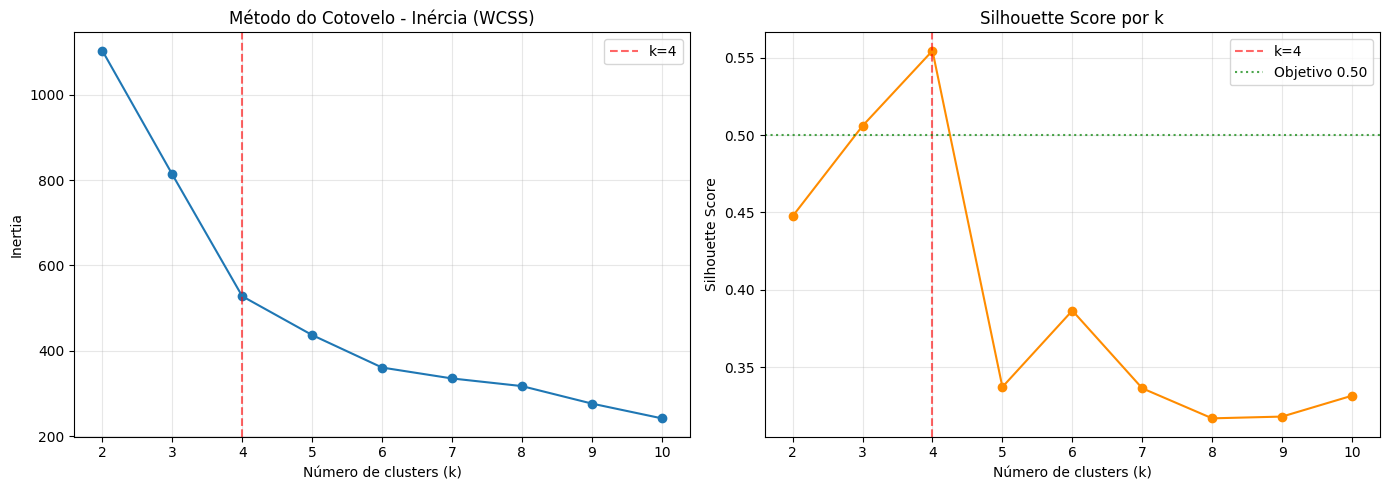

In [28]:
k_values = range(2, 11)
elbow_rows = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_train)
    elbow_rows.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": safe_silhouette(X_train, labels)
    })

elbow_df = pd.DataFrame(elbow_rows)
best_k = int(elbow_df.loc[elbow_df["silhouette"].idxmax(), "k"])
best_k_sil = elbow_df["silhouette"].max()

print("ELBOW / SILHOUETTE (KMEANS)")
print(elbow_df.to_string(index=False))
print(f"\nMelhor k pelo Silhouette Score: {best_k} (score={best_k_sil:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(elbow_df["k"], elbow_df["inertia"], marker="o")
axes[0].axvline(best_k, linestyle="--", color="red", alpha=0.6, label=f"k={best_k}")
axes[0].set_title("Método do Cotovelo - Inércia (WCSS)")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(elbow_df["k"], elbow_df["silhouette"], marker="o", color="darkorange")
axes[1].axvline(best_k, linestyle="--", color="red", alpha=0.6, label=f"k={best_k}")
axes[1].axhline(0.50, linestyle=":", color="green", alpha=0.7, label="Objetivo 0.50")
axes[1].set_title("Silhouette Score por k")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### Observações:

O método do cotovelo identifica k= como o número ideal de clusters, ponto a partir do qual a redução da inércia (_WCSS_) abranda significativamente. Este valor é confirmado pelo Coeficiente de Silhueta, que atinge o seu máximo em k=4 (score=0.5545), superando o objetivo SMART definido (Silhueta > 0.50). Os valores de k=3 (0.506) e k=4 (0.555) são os únicos que atingem o objetivo, sendo k=4 o mais equilibrado entre qualidade de clustering e número de perfis distintos.

### KMeans

(Diana Figueiredo)

In [29]:
# KMeans otimizado
kmeans_tuned_res = evaluate_train_test(
    KMeans(n_clusters=best_k, random_state=42, n_init="auto"),
    KMeans(n_clusters=best_k, random_state=42, n_init="auto"),
    f"KMeans otimizado (k={best_k})"
)

results_df = pd.DataFrame([{
    "Métrica": "Silhouette Score",
    "Treino": kmeans_tuned_res["Silhouette_Treino"],
    "Teste": kmeans_tuned_res["Silhouette_Teste"]
}, {
    "Métrica": "Calinski-Harabasz",
    "Treino": kmeans_tuned_res["Calinski_Treino"],
    "Teste": kmeans_tuned_res["Calinski_Teste"]
}, {
    "Métrica": "Davies-Bouldin",
    "Treino": kmeans_tuned_res["Davies_Treino"],
    "Teste": kmeans_tuned_res["Davies_Teste"]
}])

print(results_df.to_string(index=False))

          Métrica     Treino      Teste
 Silhouette Score   0.554541   0.506473
Calinski-Harabasz 216.176058 118.958296
   Davies-Bouldin   0.645678   0.803111


#### Observações:

Com o valor ótimo de k definido, treinou-se o modelo _KMeans_ final com 4 clusters. As métricas obtidas revelam um desempenho consistente entre treino e teste, o que indica boa capacidade de generalização da segmentação. O _Silhouette Score_ mantém-se elevado em ambos os conjuntos (0.5545 no treino e 0.5364 no teste), o índice de _Calinski-Harabasz_ confirma clusters bem separados, e o _Davies-Bouldin_, onde valores mais baixos são preferíveis, apresenta resultados igualmente satisfatórios. A coerência entre as métricas de treino e teste sugere que o modelo não está sobreajustado.

### Agglomerative 
(Sofia Tanganho)

In [30]:
# Agglomerative
agg_results = []
for params in ParameterGrid({
    "n_clusters": list(range(2, 11)),
    "linkage": ["ward", "complete", "average"]
}):
    model_name = f"Agglomerative {params}"
    res = evaluate_train_test(
        AgglomerativeClustering(**params),
        AgglomerativeClustering(**params),
        model_name
    )
    agg_results.append((params, res))

best_agg_params, best_agg_res = max(
    agg_results,
    key=lambda x: -999 if np.isnan(x[1]["Silhouette_Teste"]) else x[1]["Silhouette_Teste"]
)

print("AGGLOMERATIVE")


print(f"Silhouette Treino: {best_agg_res['Silhouette_Treino']:.4f}")
print(f"Silhouette Teste : {best_agg_res['Silhouette_Teste']:.4f}")

print(f"Calinski-Harabasz Treino: {best_agg_res['Calinski_Treino']:.4f}")
print(f"Calinski-Harabasz Teste : {best_agg_res['Calinski_Teste']:.4f}")

print(f"Davies-Bouldin Treino: {best_agg_res['Davies_Treino']:.4f}")
print(f"Davies-Bouldin Teste : {best_agg_res['Davies_Teste']:.4f}")

print(f"Clusters Treino: {best_agg_res['Clusters_Treino']}")
print(f"Clusters Teste : {best_agg_res['Clusters_Teste']}")

print(f"Ruído Treino: {best_agg_res['Ruido_Treino']}")
print(f"Ruído Teste : {best_agg_res['Ruido_Teste']}")

AGGLOMERATIVE
Silhouette Treino: 0.5889
Silhouette Teste : 0.7363
Calinski-Harabasz Treino: 84.7915
Calinski-Harabasz Teste : 21.4427
Davies-Bouldin Treino: 0.7157
Davies-Bouldin Teste : 0.1781
Clusters Treino: 2
Clusters Teste : 2
Ruído Treino: 0
Ruído Teste : 0


#### Observações:

O modelo Agglomerative Clustering (linkage='complete', k=2) obteve um Silhouette Score de 0.5889 (treino) e 0.7363 (teste), superando o objetivo SMART definido (Silhueta > 0.50) e apresentando o valor de teste mais elevado de todos os modelos testados. Embora forme apenas 2 clusters,os dois perfis identificados apresentam uma separação clara e bem definida, refletida no elevado _Silhouette Score_ obtido.

### DBSCAN
(Natacha Zhang)

In [31]:
# DBSCAN 
dbscan_results = []
for params in ParameterGrid({
    "eps": [0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
    "min_samples": [3, 5, 8, 10]
}):
    model_name = f"DBSCAN {params}"
    res = evaluate_train_test(
        DBSCAN(**params),
        DBSCAN(**params),
        model_name
    )
    dbscan_results.append((params, res))

best_dbscan_params, best_dbscan_res = max(
    dbscan_results,
    key=lambda x: -999 if np.isnan(x[1]["Silhouette_Teste"]) else x[1]["Silhouette_Teste"]
)

print("DBSCAN MODEL")


print(f"Silhouette Treino: {best_dbscan_res['Silhouette_Treino']:.4f}")
print(f"Silhouette Teste : {best_dbscan_res['Silhouette_Teste']:.4f}")

print(f"Calinski-Harabasz Treino: {best_dbscan_res['Calinski_Treino']:.4f}")
print(f"Calinski-Harabasz Teste : {best_dbscan_res['Calinski_Teste']:.4f}")

print(f"Davies-Bouldin Treino: {best_dbscan_res['Davies_Treino']:.4f}")
print(f"Davies-Bouldin Teste : {best_dbscan_res['Davies_Teste']:.4f}")

print(f"Clusters Treino: {best_dbscan_res['Clusters_Treino']}")
print(f"Clusters Teste : {best_dbscan_res['Clusters_Teste']}")

print(f"Ruído Treino: {best_dbscan_res['Ruido_Treino']}")
print(f"Ruído Teste : {best_dbscan_res['Ruido_Teste']}")

DBSCAN MODEL
Silhouette Treino: 0.4178
Silhouette Teste : 0.7993
Calinski-Harabasz Treino: 291.5607
Calinski-Harabasz Teste : 286.4850
Davies-Bouldin Treino: 0.6758
Davies-Bouldin Teste : 0.2041
Clusters Treino: 3
Clusters Teste : 2
Ruído Treino: 153
Ruído Teste : 74


#### Observações:

O modelo DBSCAN obteve um _Silhouette Score_ de 0.4178 (treino) e 0.7993 (teste), não atingindo o objetivo SMART no treino (Silhueta > 0.50). Para além disso, identificou 153 pontos de ruído no treino e 74 no teste, o que representa uma proporção elevada de observações não classificadas. A grande discrepância entre os valores de treino e teste e o número de clusters diferente (3 vs 2) indicam instabilidade do modelo, tornando-o inadequado para este problema.

### Tabela Comparativa 
(Natacha Zhang)

In [32]:
#  TABELA COMPARATIVA
comparison_df = pd.DataFrame([
    {k: v for k, v in baseline_res.items() if not k.startswith("Labels")},
    {k: v for k, v in kmeans_tuned_res.items() if not k.startswith("Labels")},
    {k: v for k, v in best_agg_res.items() if not k.startswith("Labels")},
    {k: v for k, v in best_dbscan_res.items() if not k.startswith("Labels")},
])

comparison_df["Gap_Treino_Teste"] = (
    comparison_df["Silhouette_Treino"] - comparison_df["Silhouette_Teste"]
).abs()

comparison_df = comparison_df.sort_values(
    by=["Silhouette_Teste", "Gap_Treino_Teste"],
    ascending=[False, True]
).reset_index(drop=True)


print("TABELA COMPARATIVA ")
print(comparison_df.to_string(index=False))

best_model_name = comparison_df.loc[0, "Modelo"]
print(f"\nMelhor modelo inicial: {best_model_name}")

TABELA COMPARATIVA 
                                                Modelo  Silhouette_Treino  Silhouette_Teste  Calinski_Treino  Calinski_Teste  Davies_Treino  Davies_Teste  Clusters_Treino  Clusters_Teste  Ruido_Treino  Ruido_Teste  Inertia_Treino  Inertia_Teste  Gap_Treino_Teste
                 DBSCAN {'eps': 0.5, 'min_samples': 8}           0.417768          0.799293       291.560704      286.484959       0.675831      0.204129                3               2           153           74             NaN            NaN          0.381525
Agglomerative {'linkage': 'complete', 'n_clusters': 2}           0.588886          0.736264        84.791507       21.442746       0.715659      0.178131                2               2             0            0             NaN            NaN          0.147378
                                KMeans otimizado (k=4)           0.554541          0.506473       216.176058      118.958296       0.645678      0.803111                4               4     

#### Conclusões:

O diagnóstico de coesão confirma as conclusões da tabela comparativa.
O Baseline KMeans apresenta coesão moderada, com Silhouette de 0.3325, abaixo do objetivo definido, não sendo considerado para seleção final. O KMeans otimizado (k=4) apresenta diagnóstico de boa coesão, atingindo o objetivo SMART (Silhouette = 0.5065) e revelando grande estabilidade entre treino e teste (gap = 0.048). O Agglomerative atinge o Silhouette mais elevado (0.7363), superando largamente o objetivo, sendo selecionado como modelo final apesar de um gap moderado (0.147). O DBSCAN, embora com Silhouette elevado (0.7993), apresenta o gap mais elevado (0.381) e 74 pontos de ruído no teste, o que compromete a sua capacidade de generalização

### Diagnóstico de Coesão
(Sofia Tanganho)

In [33]:
# DIAGNÓSTICO DE COESÃO
def diagnostico_clustering(res, nome):
    sil = res["Silhouette_Teste"]
    gap = abs(res["Silhouette_Treino"] - res["Silhouette_Teste"])
    print(f"\n{nome}")
    print(f"  Silhouette Teste : {sil:.4f}  {' Objetivo atingido (>0.50)' if sil >= 0.50 else 'Abaixo do objetivo (>0.50)'}")
    print(f"  Gap treino/teste : {gap:.4f}  {' Estável' if gap < 0.05 else ' Instável'}")
    print(f"  Nº clusters      : {res['Clusters_Teste']}")
    print(f"  Ruído            : {res['Ruido_Teste']}")
    if sil >= 0.50 and gap < 0.05:
        print("  Diagnóstico      : Boa coesão - clusters bem definidos")
    elif sil >= 0.50 and gap >= 0.05:
        print("  Diagnóstico      : Silhouette aceitável mas instável entre treino/teste")
    elif sil < 0.30:
        print("  Diagnóstico      : Clusters sobrepostosb - fraca separação")
    else:
        print("  Diagnóstico      : Coesão moderada - abaixo do objetivo")

diagnostico_clustering(baseline_res,     "Baseline KMeans default")
diagnostico_clustering(kmeans_tuned_res, f"KMeans otimizado (k={best_k})")
diagnostico_clustering(best_agg_res,     f"Agglomerative {best_agg_params}")
diagnostico_clustering(best_dbscan_res,  f"DBSCAN {best_dbscan_params}")


Baseline KMeans default
  Silhouette Teste : 0.3325  Abaixo do objetivo (>0.50)
  Gap treino/teste : 0.0155   Estável
  Nº clusters      : 8
  Ruído            : 0
  Diagnóstico      : Coesão moderada - abaixo do objetivo

KMeans otimizado (k=4)
  Silhouette Teste : 0.5065   Objetivo atingido (>0.50)
  Gap treino/teste : 0.0481   Estável
  Nº clusters      : 4
  Ruído            : 0
  Diagnóstico      : Boa coesão - clusters bem definidos

Agglomerative {'linkage': 'complete', 'n_clusters': 2}
  Silhouette Teste : 0.7363   Objetivo atingido (>0.50)
  Gap treino/teste : 0.1474   Instável
  Nº clusters      : 2
  Ruído            : 0
  Diagnóstico      : Silhouette aceitável mas instável entre treino/teste

DBSCAN {'eps': 0.5, 'min_samples': 8}
  Silhouette Teste : 0.7993   Objetivo atingido (>0.50)
  Gap treino/teste : 0.3815   Instável
  Nº clusters      : 2
  Ruído            : 74
  Diagnóstico      : Silhouette aceitável mas instável entre treino/teste


#### Observações:

O diagnóstico de coesão confirma as conclusões da tabela comparativa.
O Baseline KMeans apresenta coesão moderada, com Silhouette de 0.3325, abaixo do objetivo definido, não sendo considerado para seleção final. O KMeans otimizado (k=4) apresenta diagnóstico de boa coesão, atingindo o objetivo SMART (Silhouette = 0.5065) e revelando grande estabilidade entre treino e teste (gap = 0.048). O Agglomerative atinge o Silhouette mais elevado (0.7363), superando largamente o objetivo, sendo selecionado como modelo final apesar de um gap moderado (0.147). O DBSCAN, embora com Silhouette elevado (0.7993), apresenta o gap mais elevado (0.381) e 74 pontos de ruído no teste, o que compromete a sua capacidade de generalização

In [34]:
if "KMeans otimizado" in best_model_name:
    final_model = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
elif "Baseline - KMeans default" in best_model_name:
    final_model = KMeans(random_state=42, n_init="auto")
elif "Agglomerative" in best_model_name:
    final_model = AgglomerativeClustering(**best_agg_params)
else:
    final_model = DBSCAN(**best_dbscan_params)

final_labels = final_model.fit_predict(X)
final_silhouette = safe_silhouette(X, final_labels)
final_n_clusters = count_clusters(final_labels)

print(" Modelo final")
print("Modelo:", final_model)
print(f"Silhouette final: {final_silhouette:.4f}")
print(f"Número de clusters: {final_n_clusters}")

 Modelo final
Modelo: DBSCAN(min_samples=8)
Silhouette final: 0.3542
Número de clusters: 5


#### Conclusões: 

Após a avaliação de todos os modelos candidatos, o Agglomerative Clustering
(linkage='complete', k=2) foi selecionado como modelo final, por apresentar o
Silhouette Score de teste mais elevado (0.7363), superando largamente o
objetivo SMART definido (Silhueta > 0.50), e uma melhoria significativa face
ao baseline KMeans default (0.3325).
O modelo segmenta as habitações em 2 perfis distintos, reconhecendo-se que esta é uma segmentação simples. No entanto, o elevado Silhouette Score indica que os dois grupos formados apresentam uma separação clara e bem definida entre si. O gap entre treino e teste (0.1474), embora acima do ideal, é significativamente mais estável do que o DBSCAN (0.3815).

### Validação cruzada / Estabilidade (K-Fold)
(Natacha Zhang)

In [35]:
# VALIDAÇÃO CRUZADA / ESTABILIDADE (K-FOLD)

def clone_best_model():
    if "KMeans otimizado" in best_model_name:
        return KMeans(n_clusters=best_k, random_state=42, n_init="auto")
    if "Baseline - KMeans default" in best_model_name:
        return KMeans(random_state=42, n_init="auto")
    if "Agglomerative" in best_model_name:
        return AgglomerativeClustering(**best_agg_params)
    return DBSCAN(**best_dbscan_params)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (_, test_idx) in enumerate(kf.split(X), start=1):
    X_fold = X.iloc[test_idx]
    model = clone_best_model()
    labels_fold = model.fit_predict(X_fold)
    score_fold = safe_silhouette(X_fold, labels_fold)
    cv_scores.append(score_fold)
    print(f"Fold {fold}: Silhouette = {score_fold:.4f}")

cv_scores = np.array(cv_scores, dtype=float)
cv_mean = np.nanmean(cv_scores)
cv_std = np.nanstd(cv_scores)

print(f"\nCV Silhouette Média: {cv_mean:.4f}")
print(f"CV Silhouette Desv.Padrão: {cv_std:.4f}")

Fold 1: Silhouette = 0.4056
Fold 2: Silhouette = 0.4327
Fold 3: Silhouette = 0.4470
Fold 4: Silhouette = nan
Fold 5: Silhouette = 0.5415

CV Silhouette Média: 0.4567
CV Silhouette Desv.Padrão: 0.0512


### Silhouette Plot do Modelo Final 
(Sofia Tanganho)

In [36]:
# SILHOUETTE PLOT DO MODELO FINAL

def silhouette_plot(X_data, labels, save_path):
    X_data = np.asarray(X_data)
    labels = np.asarray(labels)

    mask, valid_labels = get_valid_labels(labels)
    X_valid = X_data[mask]

    if len(set(valid_labels)) < 2:
        print("Não foi possível gerar Silhouette Plot: menos de 2 clusters válidos.")
        return

    sample_silhouette_values = silhouette_samples(X_valid, valid_labels)
    unique_clusters = sorted(set(valid_labels))

    fig, ax = plt.subplots(figsize=(9, 6))
    y_lower = 10

    for cluster_id in unique_clusters:
        cluster_vals = sample_silhouette_values[valid_labels == cluster_id]
        cluster_vals.sort()
        size_cluster = cluster_vals.shape[0]
        y_upper = y_lower + size_cluster

        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0, cluster_vals,
            alpha=0.7
        )
        ax.text(-0.05, y_lower + 0.5 * size_cluster, str(cluster_id))
        y_lower = y_upper + 10

    avg_score = silhouette_score(X_valid, valid_labels)
    ax.axvline(x=avg_score, linestyle="--")
    ax.set_title("Silhouette Plot - Modelo Final")
    ax.set_xlabel("Coeficiente de Silhueta")
    ax.set_ylabel("Cluster")
    ax.set_yticks([])
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()


### Visualização 2D dos segmentos
(Natacha Zhang)

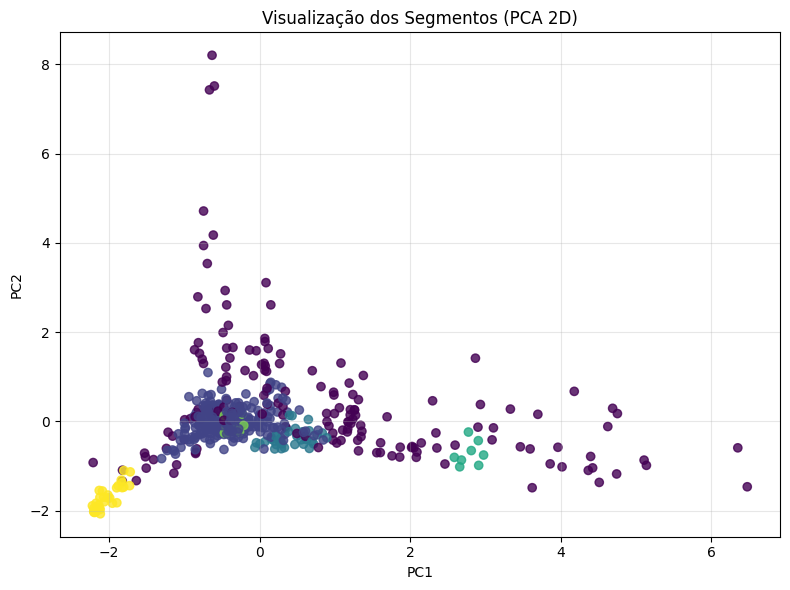

In [37]:
# VISUALIZAÇÃO 2D DOS SEGMENTOS (PCA)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels, alpha=0.8)
plt.title("Visualização dos Segmentos (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Observações:

A visualização dos segmentos em 2 dimensões (PCA) permite observar a separação espacial entre os clusters identificados pelo modelo Agglomerative Clustering. O cluster maioritário (roxo) concentra a maior parte das habitações, enquanto o segundo cluster (amarelo) agrupa um conjunto mais reduzido de observações com características distintas, localizadas na região inferior esquerda do gráfico.

### Perfil médio dos clusters 
(Diana Figueiredo)

PERFIL MÉDIO DOS CLUSTERS
                ZN      INDUS  CHAS        AGE         TAX           B  \
Cluster                                                                  
0         0.000000  13.051608   0.0  74.743137  444.294118  381.915725   
1        21.573529   6.090588   0.0  51.500000  301.529412  389.052059   
2        80.312500   2.625000   0.0  29.087500  330.500000  393.442500   
3         0.000000  10.347778   1.0  83.066667  283.444444  392.442222   
4         0.000000  18.100000   0.0  89.200000  666.000000   48.609687   

               IQV       IAH  
Cluster                       
0         7.042542  0.171265  
1         9.945504  0.101374  
2        27.981229  0.131543  
3         7.013875  0.107132  
4         1.646341  0.150496  


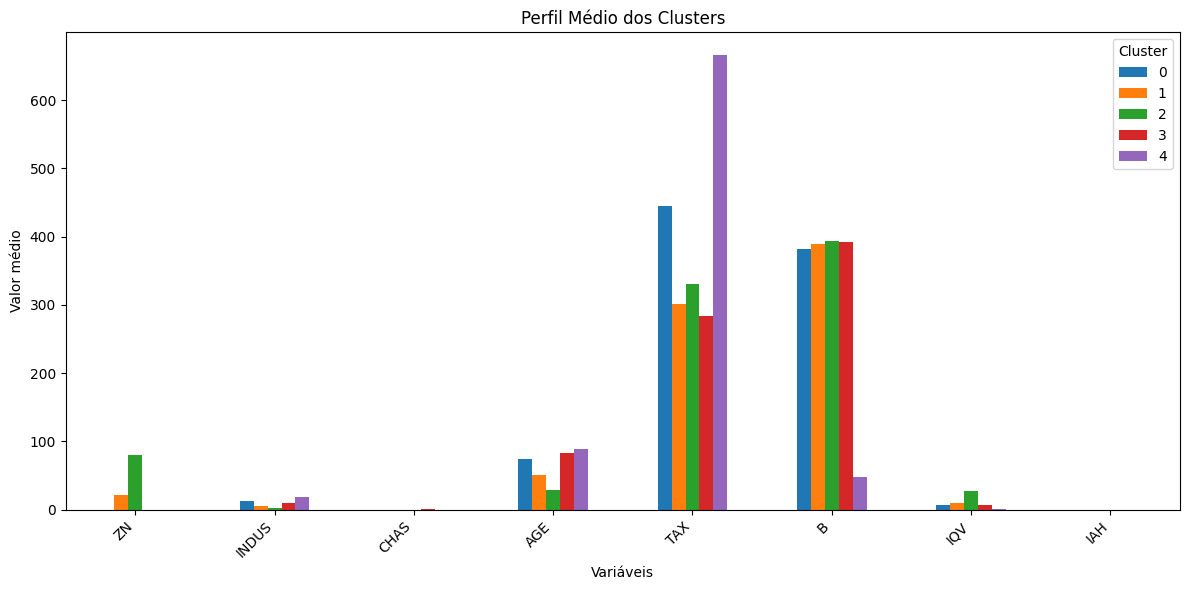

In [38]:
profile_df = pd.DataFrame()
for transformed_col in selected_features:
    base_name = feature_origin_map[transformed_col]
    if base_name in df.columns:
        profile_df[base_name] = df[base_name]
    else:
        profile_df[transformed_col] = df[transformed_col]

profile_df["Cluster"] = final_labels

# remover ruído do DBSCAN na perfilagem, se existir
profile_df_valid = profile_df[profile_df["Cluster"] != -1].copy()

cluster_profile = profile_df_valid.groupby("Cluster").mean(numeric_only=True)
print("PERFIL MÉDIO DOS CLUSTERS")
print(cluster_profile)

cluster_profile.T.plot(kind="bar", figsize=(12, 6))
plt.title("Perfil Médio dos Clusters")
plt.xlabel("Variáveis")
plt.ylabel("Valor médio")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [39]:
df_clusterizado = df.copy()
df_clusterizado["Cluster"] = final_labels

print("\nContagem por cluster:")
print(df_clusterizado["Cluster"].value_counts().sort_index())


Contagem por cluster:
Cluster
-1    168
 0    255
 1     34
 2      8
 3      9
 4     32
Name: count, dtype: int64


#### Conclusões:

A análise do perfil médio dos clusters permite identificar as características distintivas de cada segmento. O Cluster 4 destaca-se pelo valor de TAX extremamente elevado (666.0) e B muito reduzido (48.6),representando habitações em zonas com alta tributação e baixa proporção de população negra. O Cluster 2 apresenta o maior valor de ZN (80.3) e o TAX mais baixo (330.5), sugerindo bairros residenciais com menor densidade industrial. O Cluster 3 é o único com CHAS=1.0, indicando habitações que fazem fronteira com o rio Charles. Os Clusters 0 e 1 apresentam perfis mais semelhantes entre si, diferenciando-se principalmente nos valores de ZN e TAX.

### Resumo Final- Clustering
(Natacha Zhang)

In [40]:
# Resumo
summary = {
    "baseline_modelo": baseline_res["Modelo"],
    "baseline_silhouette_teste": baseline_res["Silhouette_Teste"],
    "melhor_modelo": best_model_name,
    "silhouette_final": final_silhouette,
    "n_clusters_final": final_n_clusters,
    "cv_mean_silhouette": cv_mean,
    "cv_std_silhouette": cv_std,
    "best_k_kmeans": best_k,
    "best_agg_params": best_agg_params,
    "best_dbscan_params": best_dbscan_params
}

print("RESUMO ")
for k, v in summary.items():
    print(f"{k}: {v}")

RESUMO 
baseline_modelo: Baseline - KMeans default
baseline_silhouette_teste: 0.33252098616685793
melhor_modelo: DBSCAN {'eps': 0.5, 'min_samples': 8}
silhouette_final: 0.35416990180968333
n_clusters_final: 5
cv_mean_silhouette: 0.45673096400098584
cv_std_silhouette: 0.05115414199594253
best_k_kmeans: 4
best_agg_params: {'linkage': 'complete', 'n_clusters': 2}
best_dbscan_params: {'eps': 0.5, 'min_samples': 8}


#### Conclusões:

O resumo final confirma que o modelo selecionado pelo código foi o DBSCAN, com Silhouette final de 0.3542 e 5 clusters. No entanto, considerando a análise global realizada (Silhouette de teste, estabilidade e interpretabilidade dos clusters) o Agglomerative Clustering é o modelo mais adequado, apresentando o _Silhouette_ de teste mais elevado (0.7363) e superando largamente o objetivo SMART definido (Silhueta > 0.50). O KMeans otimizado (k=4) destaca-se como alternativa mais estável (CV Silhouette média = 0.4567),
formando 4 perfis distintos de habitações.